In [254]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

def estimate_pi0_naive(D):
    """
    Provide the naive estimate of pi0 assuming zero-inflated univariate Gaussian mixtures 
    
    D is a numpy array containing fiber-densities across subjects
    """
    u0_hat = np.mean(D == 0)
    
    D_pos = D[D > 0]
    
    my_gmm = GaussianMixture(n_components=2)
    
    my_gmm.fit(D_pos.reshape(-1,1))
    
    u1_hat = my_gmm.weights_[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()]
    
    pi0_hat = u0_hat + (1-u0_hat)*u1_hat
    
    
    
    return pd.DataFrame({"pi_0":[pi0_hat[0]] ,
            "mu_FP":[my_gmm.means_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()][0]],
            "mu_TP":[my_gmm.means_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).max()][0]],
            "sigma_FP":[np.sqrt(my_gmm.covariances_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()])[0]],
            "sigma_TP":[np.sqrt(my_gmm.covariances_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).max()])[0]]})


In [255]:
pi_0 = 0.1

u_0 = 0.05

mu_0 = 0.05

sigma_0 = 0.005

mu_1 = 0.5

sigma_1 = 0.05


n_subjs = 36



non_zeros = (np.random.binomial(1,1-u_0,(n_subjs,)) == 1)

true_signal = (np.random.binomial(1,(1-pi_0)/(1-u_0),(n_subjs,)) == 1)

mean_vec = np.zeros(n_subjs)

mean_vec[non_zeros] = mu_0

mean_vec[np.logical_and(non_zeros , true_signal)] = mu_1


sd_vec = np.zeros(n_subjs)

sd_vec[non_zeros] = sigma_0

sd_vec[np.logical_and(non_zeros , true_signal)] = sigma_1


D = np.random.normal(mean_vec , sd_vec)
    
estimate_pi0_naive(D)

,pi_0,mu_FP,mu_TP,sigma_FP,sigma_TP
0,0.111111,0.043822,0.499283,0.001,0.050257


In [258]:
my_data = np.load("/Users/lradosavljevic/Downloads/SC_66sub.npy")

In [259]:
my_data.shape[:2]

(95, 95)

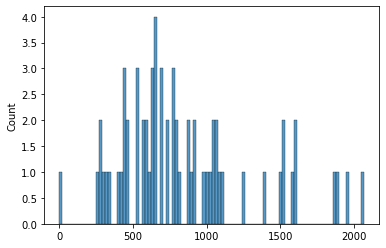

In [281]:
sns.histplot(my_data[4,4,:] , bins = 100)

In [284]:
try:
    p0 = estimate_pi0_naive(my_data[4,4,:])
except:
    p0 = 1
    

In [285]:
p0

,pi_0,mu_FP,mu_TP,sigma_FP,sigma_TP
0,0.824765,685.758486,1652.225472,243.03105,240.738479


In [188]:
my_map = np.ones(my_data.shape[:2])

In [195]:
for i in tqdm(range(my_data.shape[0])):
    for j in range(my_data.shape[0]):
        try:
            my_map[i,j] = estimate_pi0_naive(my_data[i,j,:]).pi_0.to_numpy()[0]
        except:
            continue

  0%|          | 0/95 [00:00<?, ?it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWa

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
  5%|▌         | 5/95 [00:01<00:24,  3.67it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: Conve

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1)

 21%|██        | 20/95 [00:05<00:23,  3.22it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 22%|██▏       | 21/95 [00:05<00:21,  3.51it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/s

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1)

...

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 67%|██████▋   | 64/95 [00:17<00:09,  3.35it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: Conv

 76%|███████▌  | 72/95 [00:19<00:06,  3.64it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 77%|███████▋  | 73/95 [00:20<00:05,  3.88it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/s

 82%|████████▏ | 78/95 [00:21<00:04,  3.99it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: Conv

 93%|█████████▎| 88/95 [00:23<00:01,  3.84it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 94%|█████████▎| 89/95 [00:24<00:01,  3.91it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/s

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 98%|█████████▊| 93/95 [00:24<00:00,  4.58it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: Conv

In [196]:
my_map

array([[0.35846732, 0.62300189, 0.88726554, ..., 1.        , 1.        ,
        0.98484848],
       [0.62300189, 0.74559495, 0.83759918, ..., 1.        , 1.        ,
        0.54700619],
       [0.75465586, 0.83759918, 0.65908787, ..., 1.        , 1.        ,
        0.93939177],
       ...,
       [1.        , 1.        , 1.        , ..., 0.98484848, 0.98484848,
        0.80865124],
       [1.        , 1.        , 1.        , ..., 0.98484848, 0.92906481,
        0.98484848],
       [0.98484848, 0.54700619, 0.93939177, ..., 0.98484848, 0.98484848,
        0.46800528]])

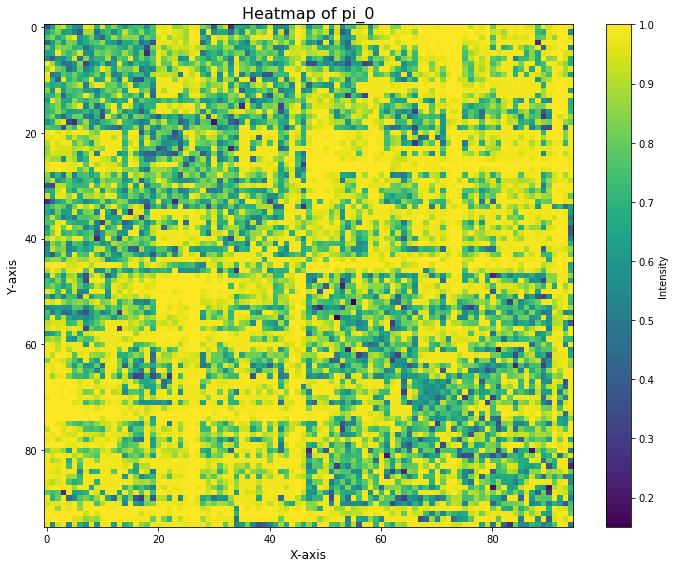

In [225]:
plt.figure(figsize=(10, 8))                  # Size in inches (width, height)
plt.imshow(my_map, cmap='viridis', aspect='auto')  # auto to avoid squishing
plt.colorbar(label='Intensity')
plt.title('Heatmap of pi_0', fontsize=16)
plt.xlabel('X-axis', fontsize=12)
plt.ylabel('Y-axis', fontsize=12)
plt.tight_layout()
plt.show()

TypeError: alpha must be a float or None

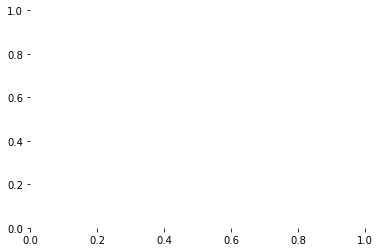

In [241]:

sns.heatmap(my_map, cmap="viridis", cbar=True, alpha=my_alpha_map)

In [244]:
my_alpha_map

array([[0. , 0. , 0. , ..., 0.5, 0.5, 0. ],
       [0. , 0. , 0. , ..., 0.5, 0.5, 0. ],
       [0. , 0. , 0. , ..., 0.5, 0.5, 0. ],
       ...,
       [0.5, 0.5, 0.5, ..., 0. , 0. , 0. ],
       [0.5, 0.5, 0.5, ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ]])

In [216]:
my_alpha_map.shape

(95, 95)

In [206]:
my_map.shape

(95, 95)

In [212]:
my_alpha_map = (0.5*(my_map == 1.0).astype(float))

In [213]:
my_alpha_map.shape

(95, 95)

In [243]:
my_alpha_map.isnan()

AttributeError: 'numpy.ndarray' object has no attribute 'isnan'